# Module 4 — ONS Mortality by Region (2024)

**Goal:** bring in eating-disorder-related mortality (ICD-10 F50) as a complementary, more severe outcome measure alongside hospital admissions.

**Source:** ONS via Nomis, *Mortality statistics — underlying cause, sex and age*, 2024, England & Wales regions.

## 1. Load

In [1]:
import sys, os
from pathlib import Path

p = Path.cwd()
while not (p / "README.md").exists() and p != p.parent:
    p = p.parent

os.chdir(p)
if str(p / "src") not in sys.path:
    sys.path.insert(0, str(p / "src"))

print("Working directory set to:", os.getcwd())

Working directory set to: c:\PROJECTSSSSS\uk-ed-analytics


In [2]:
import sys
sys.path.append('src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from load_ons_mortality import load as load_mortality
df = load_mortality()
df

,region,all_cause_deaths,ed_deaths,ed_death_rate_per_100k_allcause
0,North East,29785,1,3.357395
1,North West,76775,2,2.605015
2,Yorkshire and The Humber,56469,2,3.541766
3,East Midlands,49519,3,6.058281
4,West Midlands,59301,1,1.686312
5,East,60809,3,4.933480
6,London,50560,7,13.844937
7,South East,87449,9,10.291713
8,South West,61287,6,9.790004
9,Wales,35404,7,19.771777


## 2. Regional breakdown

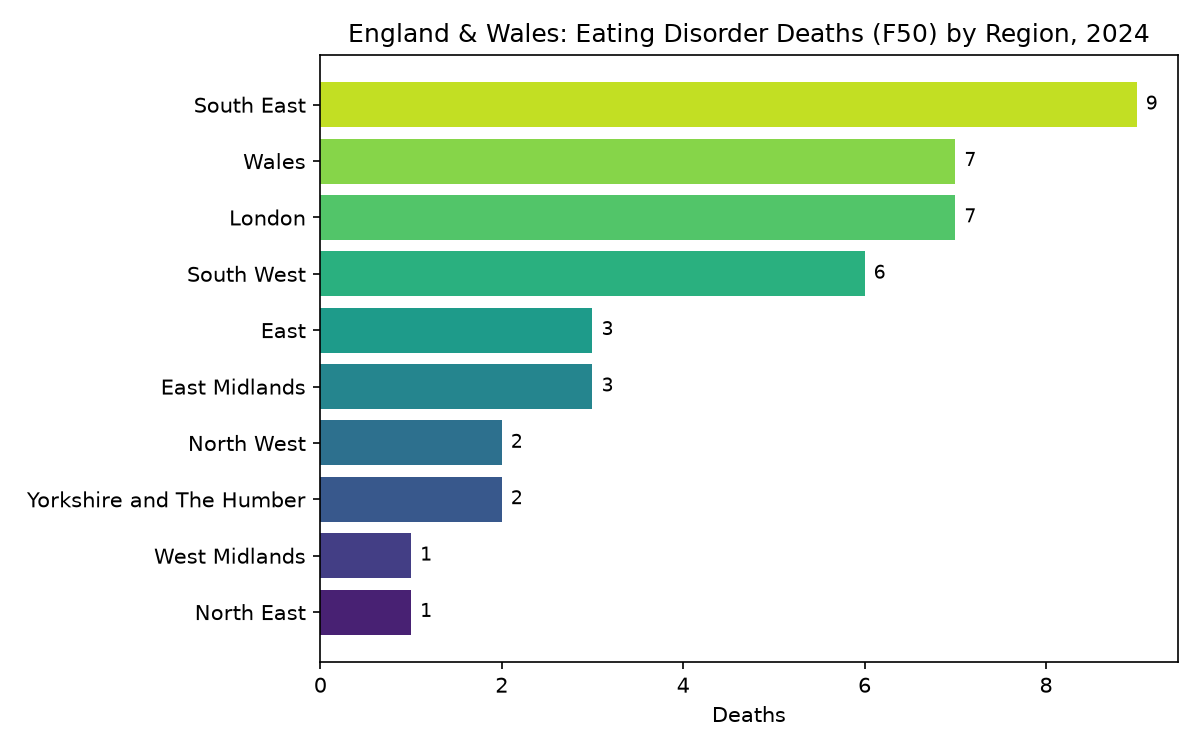

In [3]:
from IPython.display import Image
Image('reports/figures/ons_mortality_by_region.png')

In [4]:
total_ed_deaths = df.loc[df['region']=='Column Total', 'ed_deaths'].values[0] \
    if 'Column Total' in df['region'].values else df['ed_deaths'].sum()
print(f"Total eating-disorder-coded deaths, England & Wales, 2024: {int(total_ed_deaths)}")

Total eating-disorder-coded deaths, England & Wales, 2024: 41


**⚠️ Honesty note — read this before drawing conclusions:** these are very small counts (South East highest at 9, several regions at just 1). Normal year-to-year noise can easily produce differences of this size by chance. **Don't over-read the regional ranking as a "riskier region" finding** — it's useful context, not a statistically reliable signal on its own. This would need multiple years pooled together (or a rate-based, population-adjusted comparison) to say anything confident about regional differences.

## 3. Mortality relative to all-cause deaths

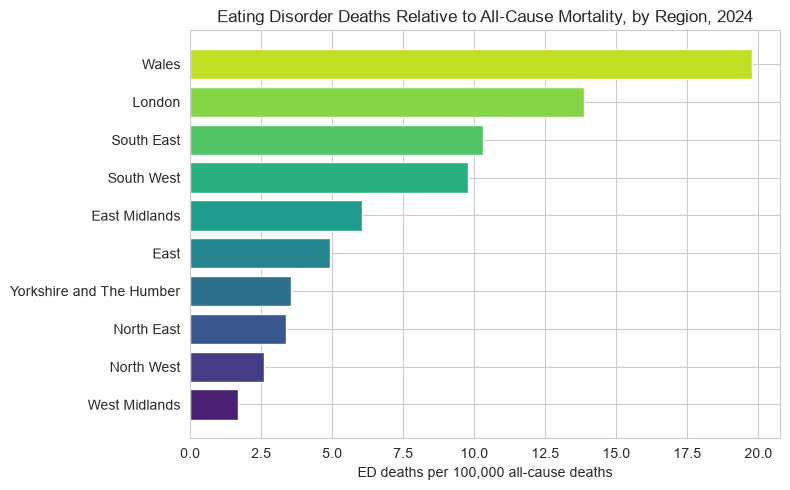

In [5]:
d = df[~df['region'].isin(['Column Total', 'Unknown or Abroad'])].sort_values('ed_death_rate_per_100k_allcause', ascending=True)

plt.figure(figsize=(8,5))
plt.barh(d['region'], d['ed_death_rate_per_100k_allcause'], color=sns.color_palette('viridis', len(d)))
plt.xlabel('ED deaths per 100,000 all-cause deaths')
plt.title('Eating Disorder Deaths Relative to All-Cause Mortality, by Region, 2024')
plt.tight_layout()
plt.show()

**Reading this:** normalizing by each region's total death volume changes the picture a little — Wales stands out more once you account for its smaller population/death volume relative to somewhere like the South East. Again, treat as a single-year snapshot with small counts, not a firm conclusion.

## Takeaways

- 41 total eating-disorder-coded deaths across England & Wales in 2024 — a small-numbers dataset that deserves cautious interpretation
- Admissions (Module 2/3) tell a far more statistically reliable story than this mortality snapshot does
- If you can find multiple years of this mortality data, pooling them would substantially strengthen any regional claim


